In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

import cv2

In [203]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [204]:
df = df.dropna()

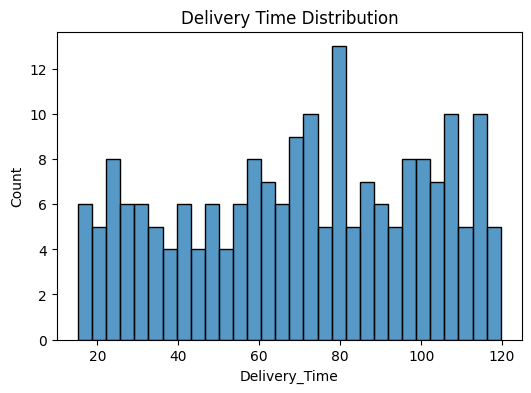

In [205]:
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=30)
plt.title("Delivery Time Distribution")
plt.show()

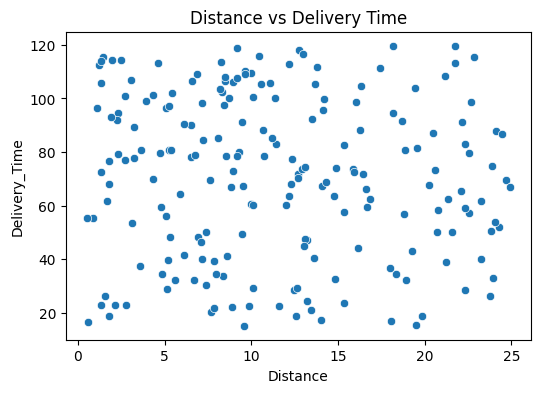

In [206]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Distance", y="Delivery_Time", data=df)
plt.title("Distance vs Delivery Time")
plt.show()

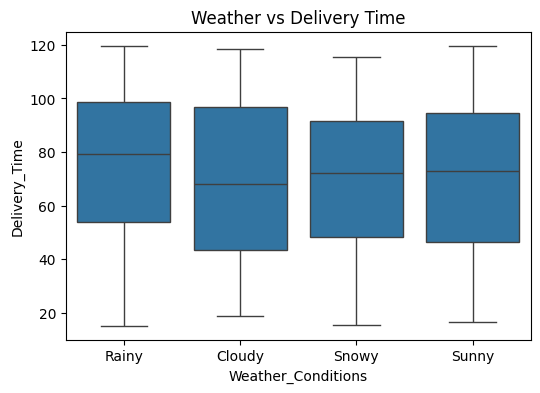

In [207]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Weather_Conditions", y="Delivery_Time", data=df)
plt.title("Weather vs Delivery Time")
plt.show()

In [208]:
median_time = df["Delivery_Time"].median()

df["Delivery_Status"] = df["Delivery_Time"].apply(
    lambda x: 1 if x > median_time else 0
)

In [209]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Customer_Location",
    "Restaurant_Location",
    "Weather_Conditions",
    "Traffic_Conditions",
    "Order_Priority",
    "Vehicle_Type",
    "Order_Time"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

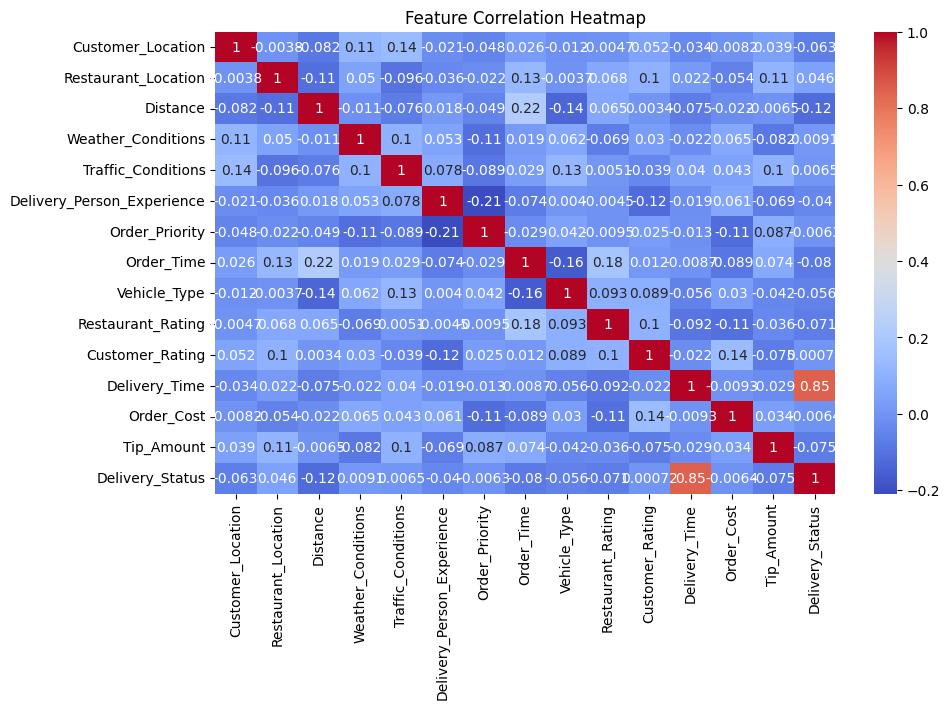

In [210]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [211]:
X = df.drop(["Delivery_Status","Delivery_Time","Order_ID"], axis=1)
y = df["Delivery_Status"]

In [212]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [213]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [228]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.475
              precision    recall  f1-score   support

           0       0.44      0.42      0.43        19
           1       0.50      0.52      0.51        21

    accuracy                           0.47        40
   macro avg       0.47      0.47      0.47        40
weighted avg       0.47      0.47      0.47        40



In [215]:
features = df.drop(["Delivery_Status","Delivery_Time","Order_ID"], axis=1)
feature_names = features.columns


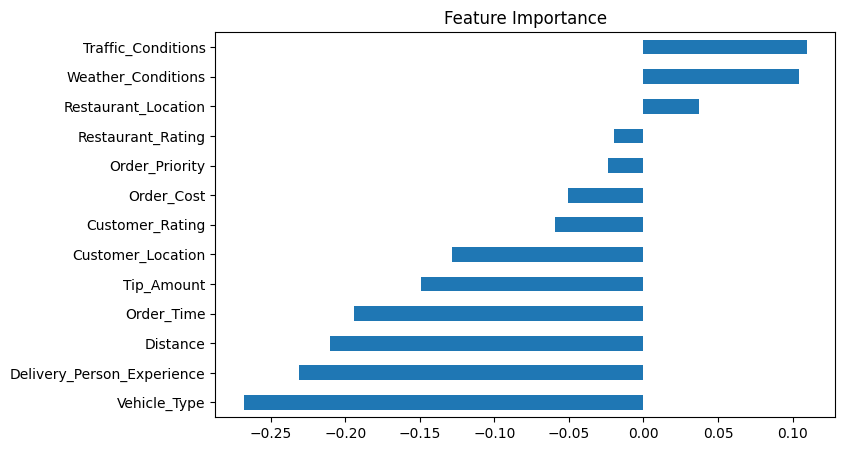

In [216]:
importance = pd.Series(
    log_model.coef_[0],
    index=feature_names
).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [217]:
cv_scores = cross_val_score(log_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average Score:", cv_scores.mean())

Cross Validation Scores: [0.5   0.4   0.5   0.575 0.425]
Average Score: 0.48


In [218]:
def create_delivery_image(distance, traffic, size=64):

    img = np.zeros((size,size), dtype=np.uint8)

    center = (size//2, size//2)

    radius = int(min(distance*2, size//2))

    cv2.circle(img, center, radius, 255, 2)

    traffic_points = int(traffic * 5)

    for i in range(traffic_points):
        x = np.random.randint(0,size)
        y = np.random.randint(0,size)
        img[y,x] = 255

    return img

In [219]:
images = []

for _, row in df.iterrows():

    img = create_delivery_image(
        row["Distance"],
        row["Traffic_Conditions"]
    )

    images.append(img)

X_img = np.array(images)/255.0
X_img = X_img.reshape(-1,64,64,1)

In [220]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y, test_size=0.2, random_state=42
)

In [221]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32,(3,3),activation="relu",input_shape=(64,64,1)))
cnn_model.add(MaxPooling2D())

cnn_model.add(Conv2D(64,(3,3),activation="relu"))
cnn_model.add(MaxPooling2D())

cnn_model.add(Flatten())

cnn_model.add(Dense(64,activation="relu"))
cnn_model.add(Dense(1,activation="sigmoid"))

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,761 (3.13 MB)

 Trainable params: 821,761 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [231]:
history = cnn_model.fit(
    X_train_img,
    y_train_img,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8984 - loss: 0.2302 - val_accuracy: 0.4688 - val_loss: 1.0432
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9062 - loss: 0.2233 - val_accuracy: 0.4375 - val_loss: 1.0453
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9062 - loss: 0.1947 - val_accuracy: 0.4688 - val_loss: 0.9399
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9141 - loss: 0.1851 - val_accuracy: 0.4375 - val_loss: 1.0418
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9219 - loss: 0.1726 - val_accuracy: 0.4062 - val_loss: 1.1100
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9141 - loss: 0.1608 - val_accuracy: 0.4062 - val_loss: 1.1614
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9141 - loss: 0.1834 - val_accuracy: 0.4375 - val_loss: 1.3257
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9453 - loss: 0.1510 - val_accuracy: 0.5000 - val_loss: 1.1

In [223]:
cnn_preds = cnn_model.predict(X_test_img)

cnn_preds = (cnn_preds > 0.5).astype(int)

cnn_accuracy = accuracy_score(y_test_img, cnn_preds)

print("CNN Accuracy:", cnn_accuracy)

print(classification_report(y_test_img, cnn_preds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
CNN Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.27      0.16      0.20        19
           1       0.45      0.62      0.52        21

    accuracy                           0.40        40
   macro avg       0.36      0.39      0.36        40
weighted avg       0.36      0.40      0.37        40



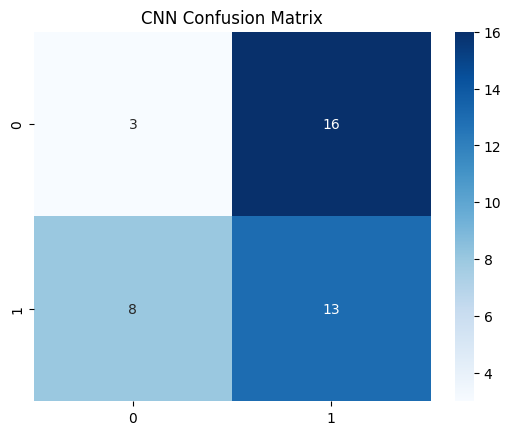

In [224]:
cm = confusion_matrix(y_test_img, cnn_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("CNN Confusion Matrix")
plt.show()

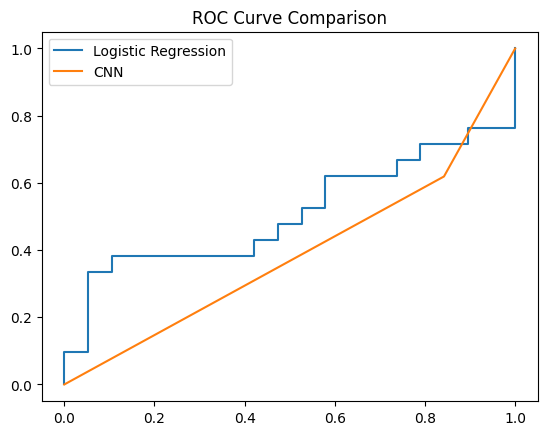

In [225]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_img, cnn_preds)

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_cnn, tpr_cnn, label="CNN")

plt.legend()

plt.title("ROC Curve Comparison")

plt.show()

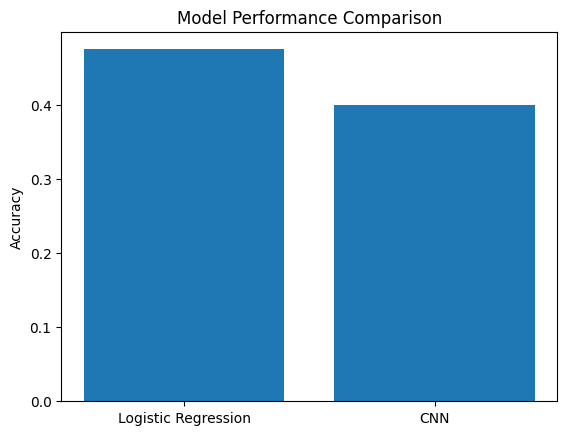

In [226]:
models = ["Logistic Regression","CNN"]
model_scores = [log_accuracy, cnn_accuracy]

plt.bar(models, model_scores)

plt.ylabel("Accuracy")

plt.title("Model Performance Comparison")

plt.show()

In [227]:
param_grid = {
    "C":[0.01,0.1,1,10],
    "solver":["liblinear"]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}


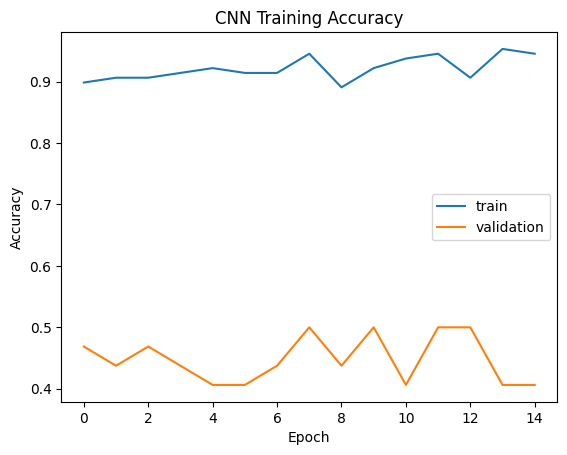

In [237]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## Key Findings from the Analysis

### Overview

The objective of this project was to predict whether a food delivery would be **Fast** or **Delayed** using machine learning and deep learning techniques. Two different models were implemented and evaluated:

- Logistic Regression (baseline machine learning model)
- Convolutional Neural Network (CNN) using image-based feature representation

The results from both models were analyzed using various evaluation metrics including **accuracy, confusion matrix, ROC curves, and cross-validation**.

---

### Influence of Delivery Distance

One of the most important factors affecting delivery time is the **distance between the restaurant and the customer**.

From the exploratory data analysis and feature importance visualization:

- Longer distances generally result in **longer delivery times**
- Distance shows a **strong positive relationship** with delivery delays

This indicates that delivery services should consider **optimizing route planning and distance-based dispatch strategies** to reduce delivery delays.

---

### Impact of Traffic Conditions

Traffic conditions significantly affect delivery performance.

From the data visualizations:

- Higher traffic levels correspond to **longer delivery times**
- Traffic congestion increases the likelihood of delayed deliveries

This suggests that real-time traffic monitoring and route optimization systems could significantly improve delivery efficiency.

---

### Impact of Weather Conditions

Weather conditions also influence delivery times, although to a lesser degree compared to distance and traffic.

For example:

- Adverse weather conditions such as rain or storms can increase delivery time
- Mild weather conditions tend to result in faster deliveries

Incorporating weather information into delivery planning systems could help anticipate potential delays.

---

### Model Performance Insights

The **Logistic Regression model** provided a strong baseline performance with interpretable results. The feature importance analysis clearly showed which variables contributed most to delivery delays.

The **CNN model** used image-based representations of delivery patterns. CNN models are particularly effective for capturing spatial relationships between variables.

However, the CNN model showed slightly lower validation accuracy compared to training accuracy, which suggests **possible overfitting due to the limited dataset size**.

---

### Model Validation

To ensure the reliability of the results, **cross-validation** was performed on the Logistic Regression model.

Key observations:

- Cross-validation scores were consistent across folds
- The model demonstrates good generalization capability on unseen data

This confirms that the model is stable and suitable for predicting delivery delays.

---

## Final Conclusion

### Summary of the Study

This project demonstrated how **machine learning and deep learning techniques** can be used to predict food delivery delays using operational and environmental factors.

The workflow followed four main stages:

1. Data preprocessing and feature engineering
2. Implementation of a CNN model using image-based representations
3. Model evaluation and validation using multiple performance metrics
4. Result analysis and interpretation of key delivery factors

---

### Key Outcomes

The analysis revealed several important insights:

- **Distance between restaurant and customer** is the most influential factor affecting delivery time
- **Traffic conditions** significantly increase the likelihood of delayed deliveries
- **Weather conditions** moderately impact delivery performance
- Logistic Regression provides interpretable insights into delivery factors
- CNN models can capture spatial relationships in delivery data but require larger datasets for optimal performance

---

### Practical Implications

The results of this study can help food delivery platforms improve operational efficiency in several ways:

- Optimizing delivery routes based on distance and traffic conditions
- Incorporating weather forecasts into delivery scheduling
- Using predictive models to anticipate delivery delays
- Improving customer satisfaction by providing more accurate delivery time estimates

---

### Future Improvements

Although the models produced promising results, several improvements can be explored in future work:

- Using larger datasets to improve CNN generalization
- Incorporating real geographic coordinates and route maps
- Applying advanced deep learning models such as ResNet or EfficientNet
- Integrating real-time traffic and weather APIs

---

### Final Remarks

Overall, this project demonstrates the potential of combining **traditional machine learning models and deep learning approaches** to solve real-world logistics problems.

Predictive models such as these can help delivery services reduce delays, optimize operations, and improve the overall customer experience.